## Figure 1 plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from results_processing import process_cluster_report, process_cluster_tsv, assign_nested_clusters

# Global plot formatting
plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [2]:
def add_ground_truth(df, annotations):
    merge = pd.merge(df, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='query', right_on='fullID', how='left').drop('fullID',axis=1)
    merge.rename(columns={'trueClusters':'if1clust','pairID':'pfamID1','ClusterID':'pfamclust1'}, inplace=True)
    merge2 = pd.merge(merge, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='target', right_on='fullID', how='left').drop('fullID',axis=1)
    merge2.rename(columns={'trueClusters':'if2clust','pairID':'pfamID2','ClusterID':'pfamclust2'}, inplace=True)

    # Create agreement label to distinguish 'similar' from 'dissimilar' interfaces based on cluster assignment
    merge2.loc[merge2['if1clust'] == merge2['if2clust'], 'agreement'] = 'Same cluster'
    merge2['agreement'] = merge2['agreement'].fillna('Different cluster')

    return merge2

## Load datasets

In [ ]:
# From annotations/add_annot_to_clusters.ipynb
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters['chain_id_0'] = pdb_clusters['chain_id_0'].fillna('NA')
pdb_clusters['chain_id_1'] = pdb_clusters['chain_id_1'].fillna('NA')
pdb_clusters['chains_sorted'] = pdb_clusters[['chain_id_0','chain_id_1']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
pdb_clusters.loc[:,'simple_pdb_id'] = [x[:4] for x in pdb_clusters['pdb_id']]
pdb_clusters['full_lookup_id'] = pdb_clusters[['simple_pdb_id','chains_sorted']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)

# From create_dis-ord_benchmark_dataset.ipynb
dmi_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/dmi_clusters.csv")
# From create_ord-ord_benchmark_dataset.ipynb
ddi_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/ddi_clusters.csv')

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_22812/3168642018.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


## Panel c

In [ ]:
# Accuracy numbers are AUROC1 values calculated in figureS1.ipynb
accs_ddi = [0.966, 0.946, 0.949]
accs_dmi = [0.789, 0.800, 0.809]
times_ddi = [0.020, 3.58, 4.72]
times_dmi = [0.019, 1.63, 2.07]
fold_times_ddi = [np.log2(4.72 / x) for x in times_ddi]
fold_times_dmi = [np.log2(2.07 / x) for x in times_dmi]
print(fold_times_ddi, fold_times_dmi)

[7.882643049361841, 0.3988272720975848, 0.0] [6.767487538943102, 0.3447588032682477, 0.0]


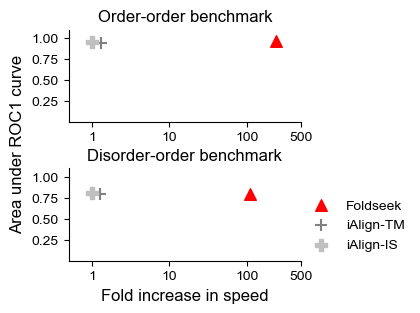

In [5]:
plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['mathtext.default'] = 'default'

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(3,3))
fig.subplots_adjust(hspace=0.5)
fig.set_facecolor('white') #3F3F3F for presentations
ax1.set_facecolor('white')
ax2.set_facecolor('white')
ax1.spines.left.set_color('black')
ax2.spines.left.set_color('black')
ax2.spines.bottom.set_color('black')
ax1.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')
ax2.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')

ax1.set_ylim(0, 1.10)
ax2.set_ylim(0, 1.10)

ax1.set_xlim(-1, 8)
ax2.set_xlim(-1, 8)

ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.set_xticklabels([])
ax2.set_xticks([0, np.log2(10), np.log2(100), np.log2(500)])
ax2.set_xticklabels(["1", "10", "100", "500"])
ax1.set_xticks([0, np.log2(10), np.log2(100), np.log2(500)])
ax1.set_xticklabels(["1", "10", "100", "500"])

ax2.set_xlabel("Fold increase in speed", fontsize=12)
fig.text(-0.02, 0.5, 'Area under ROC1 curve', va='center', ha='right', rotation='vertical', fontsize=12)

ax1.set_title("Order-order benchmark", fontsize=12)
ax2.set_title("Disorder-order benchmark", fontsize=12)

#Plot
ax1.scatter([fold_times_ddi[0]], [accs_ddi[0]], color='red', marker="^", s=70, label="Foldseek")
ax1.scatter([fold_times_ddi[1]], [accs_ddi[1]], color='gray', marker="+", s=70, label="iAlign-TM")
ax1.scatter([fold_times_ddi[2]], [accs_ddi[2]], color='silver', marker="P", s=70, label="iAlign-IS")
ax2.scatter([fold_times_dmi[0]], [accs_dmi[0]], color='red', marker="^", s=70, label="Foldseek")
ax2.scatter([fold_times_dmi[1]], [accs_dmi[1]], color='gray', marker="+", s=70, label="iAlign-TM")
ax2.scatter([fold_times_dmi[2]], [accs_dmi[2]], color='silver', marker="P", s=70, label="iAlign-IS")

ax2.legend(loc=0, bbox_to_anchor=(1.5,0.8), frameon=False, fontsize=10, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_acc_runtime.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_acc_runtime.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')